# OCT retinal disease classification. Data exploration

This notebook examines the Kermany OCT2017 dataset, which contains retinal OCT B-scans in four classes, namely CNV, DME, DRUSEN, and NORMAL. This is the dataset on which the model is trained, and it is therefore the dataset that must be understood and cleaned before modelling.

The exploration pursues three objectives. The first is to characterise the class distribution and the image content. The second is to test whether the provided train and test split can be trusted. The third is to measure how the training set differs in size and aspect ratio from the devices on which the model will later be evaluated. Each objective leads to a decision that constrains the preprocessing and the evaluation in the notebooks that follow.

## Imports

The following cell imports the libraries used throughout the notebook together with the project configuration, which defines the dataset paths, the class names, and the random seed.

In [1]:
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# project configuration with dataset paths and class names
from ocular import config

%matplotlib inline

Paths, the class order and the seed are read from one module, so every notebook and script resolves them the same way. Its source is shown below.

In [2]:
import inspect
from IPython.display import display, Code



def show_src(*objs):
    """Display the live source of each function, class or module."""
    for o in objs:
        display(Code(inspect.getsource(o), language="python"))

In [3]:
show_src(config)

"""Project-wide configuration for the ocular package.

This module centralises the filesystem layout, the class vocabulary, and the
global random seed, so that every other module and notebook resolves paths and
labels from a single source of truth.

Attributes
----------
ROOT : pathlib.Path
    Repository root, resolved relative to this file.
DATA_DIR : pathlib.Path
    Root of the data tree (``data/``).
REPORTS_DIR : pathlib.Path
    Directory holding the de-identified clinic reports.
TRAINING_DIR : pathlib.Path
    Kermany OCT2017 training split, with one subdirectory per class.
TESTING_DIR : pathlib.Path
    Kermany OCT2017 test split, with one subdirectory per class.
CLASSES : list of str
    The four diagnostic classes in fixed order. This order defines the integer
    label encoding and the column order of every model output.
SEED : int
    Global random seed for reproducible data splits and training.
"""
from pathlib import Path

# Filesystem layout. All paths are absolute and derived from the repository root.
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "Reports"
TRAINING_DIR = DATA_DIR / "raw" / "OCT2017" / "train"
TESTING_DIR = DATA_DIR / "raw" / "OCT2017" / "test"

# Diagnostic classes in fixed order. This defines the integer label encoding
# and the column order of every model head.
CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

# Global random seed for reproducible data splits and training.
SEED = 0

## Datasets and their roles

The central difficulty of the task is not classification on a single device but classification on devices the model has never seen. To measure this, the model is trained on one scanner and evaluated on two others that are held out entirely. Each dataset originates from a different OCT device.

| Dataset | Scanner | Role | Images |
|---|---|---|---|
| Kermany | Heidelberg Spectralis | training set | 83,484 |
| OCTDL | Optovue Avanti | evaluation set (unseen) | 1,137 |
| Clinic | OPTOPOL REVO | target set | 37 |

OCTDL serves as the primary evaluation set and contains all four classes. The clinic set is the deployment target and measures performance on real reports. The Kermany dataset provides a built-in split of 83,484 training images and 1,000 test images at 250 per class. The remainder of this notebook focuses on Kermany, because that is the data used for training. The evaluation sets return in the modelling notebook.

## Loading the dataset

The Kermany dataset resides in the folder data/raw/OCT2017 and is organised into a training and a testing directory, each containing one subdirectory per class. The following cells load the image paths and their labels for both splits.

Total training images 83484
CNV      37205
DME      11348
DRUSEN   8616
NORMAL   26315


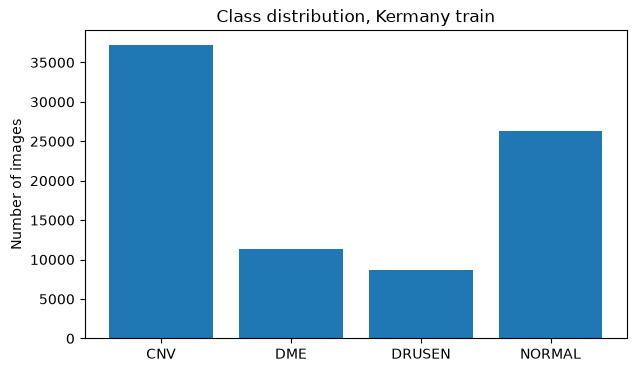

In [4]:
training_paths = []
training_labels = []

for cls in config.CLASSES:
    files = sorted((config.TRAINING_DIR / cls).glob("*.jpeg"))
    training_paths.extend(files)
    training_labels.extend([cls] * len(files))

training_counts = []
print(f"Total training images {len(training_paths)}")
for cls in config.CLASSES:
    training_counts.append(training_labels.count(cls))
    print(f"{cls:8s} {training_labels.count(cls)}")

plt.figure(figsize=(7, 4))
plt.bar(config.CLASSES, training_counts)
plt.ylabel("Number of images")
plt.title("Class distribution, Kermany train")
plt.show()

In [5]:
test_paths = []
test_labels = []

for cls in config.CLASSES:
    files = sorted((config.TESTING_DIR / cls).glob("*.jpeg"))
    test_paths.extend(files)
    test_labels.extend([cls] * len(files))

print(f"Total testing images {len(test_paths)}")
for cls in config.CLASSES:
    print(f"{cls:8s} {test_labels.count(cls)}")

Total testing images 1000
CNV      250
DME      250
DRUSEN   250
NORMAL   250


**Observation.** The training set is imbalanced. The majority class is CNV with roughly 37,000 images, while the smallest class is DRUSEN with roughly 8,600 images. The test set, in contrast, is balanced at 250 images per class.

**Decision.** The imbalance is not addressed by discarding data. It is handled during training through class weights, so that every image contributes while the rarer classes are weighted more heavily. This retains the full dataset and is configured in the modelling notebook.

## Sample images per class

To develop an intuition for the appearance of each class, the following cell displays several representative images per class.

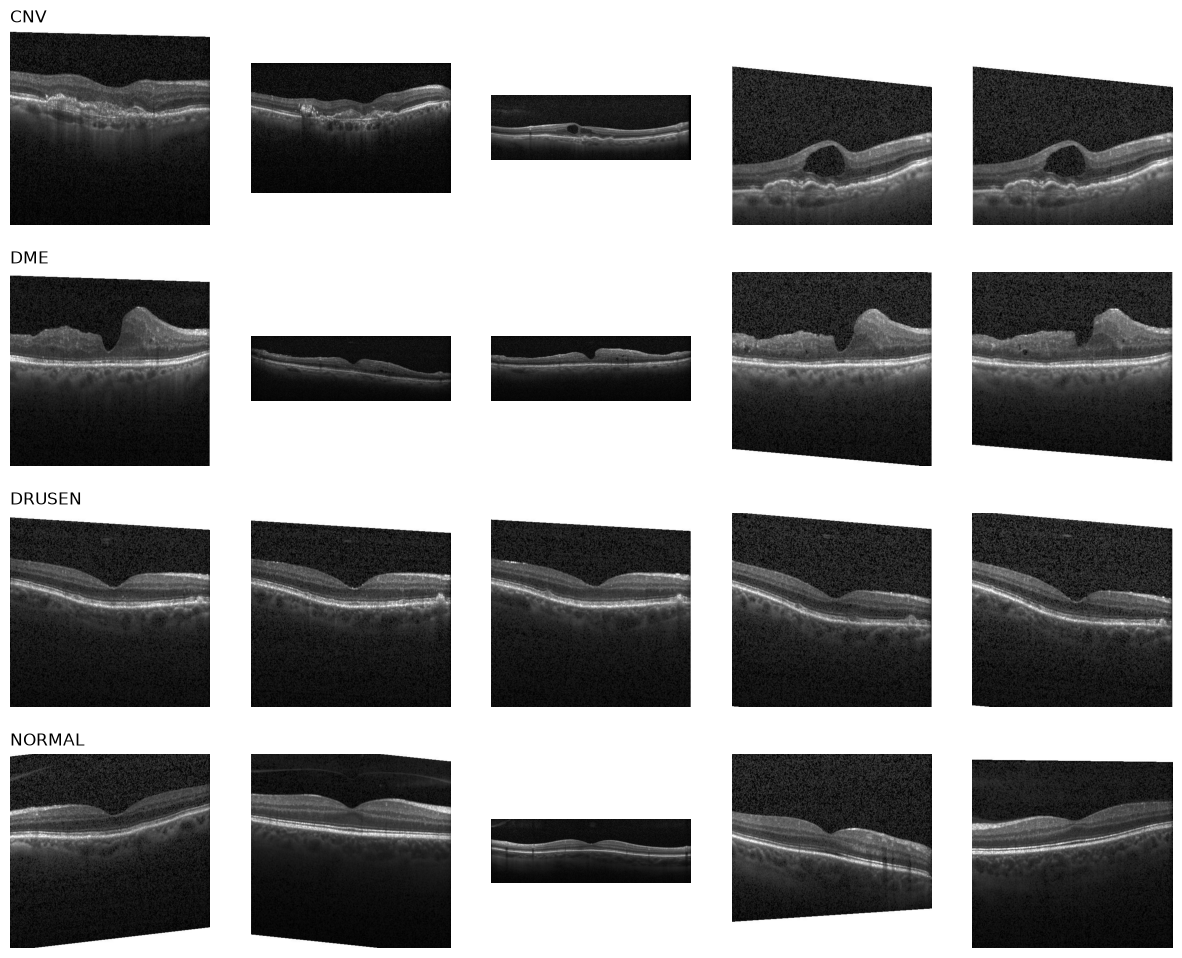

In [6]:
n = 5  # images shown per class

fig, axes = plt.subplots(4, n, figsize=(3 * n, 12))

for row, cls in enumerate(config.CLASSES):
    files = sorted((config.TRAINING_DIR / cls).glob("*.jpeg"))[:n]
    for col, path in enumerate(files):
        ax = axes[row, col]
        ax.imshow(Image.open(path), cmap="gray")
        ax.axis("off")
    axes[row, 0].set_title(cls, loc="left")

plt.show()

## Patient leakage in the provided split

The dataset is distributed with a ready-made train and test split. This section tests whether that split is free of patient leakage.

Each filename follows the pattern CLASS-PATIENT-SLICE.jpeg, so the patient identifier is embedded in the name. A single patient contributes many images, which are different slices of the same eye. If some slices of a patient appear in the training set while others appear in the test set, the model is evaluated on eyes it has already seen during training. The following cell measures the overlap of patient identifiers between the two splits.

In [7]:
def patients_in(folder):
    """Return the set of patient identifiers present in a data folder.

    The patient identifier is the second field of the filename, which follows
    the pattern CLASS-PATIENT-SLICE.jpeg.
    """
    ids = set()
    for cls in config.CLASSES:
        for img in (folder / cls).glob("*.jpeg"):
            patient = img.name.split("-")[1]
            ids.add(patient)
    return ids


train_patients = patients_in(config.TRAINING_DIR)
test_patients = patients_in(config.TESTING_DIR)
shared = train_patients & test_patients

print("Training patients", len(train_patients))
print("Testing patients", len(test_patients))
print("Shared patients", len(shared))
print(f"Leakage {100 * len(shared) / len(test_patients):.0f} percent of the test set is also in training")

Training patients 4590
Testing patients 633
Shared patients 566
Leakage 89 percent of the test set is also in training


**Finding.** 89 percent of the test patients also appear in the training set. Accuracy measured on the provided split is therefore inflated, because the model is evaluated mostly on eyes it has already seen. This is a known property of the dataset. Tampu and colleagues report 92 percent for the same dataset in 2022, which is close to the value measured here.

**Correction.** The split is rebuilt at the level of the patient, so that all slices of a given patient are assigned entirely to training or entirely to validation. This is the only construction under which the validation set measures generalisation to unseen eyes.

## Building a clean split

The split is now rebuilt to remove the patient leakage. Every image is retained rather than discarded, because the differences in image size are normalised later by the preprocessing and therefore do not require dropping data. Approximately ten percent of the patients are held out for validation, and no patient is divided between the two sides.

In [8]:
rows = []
for cls in config.CLASSES:
    for img in (config.TRAINING_DIR / cls).glob("*.jpeg"):
        rows.append({"filename": img.name, "class": cls,
                     "patient": img.name.split("-")[1]})

df = pd.DataFrame(rows)

# assign about ten percent of the patients to validation without splitting a patient
patients = sorted(df["patient"].unique())
random.seed(config.SEED)
random.shuffle(patients)
val_patients = set(patients[:int(0.10 * len(patients))])
df["split"] = df["patient"].apply(lambda p: "val" if p in val_patients else "train")

df.to_csv(config.DATA_DIR / "split.csv", index=False)
print("Saved", len(df), "images to split.csv")
print(pd.crosstab(df["class"], df["split"]))

Saved 83484 images to split.csv
split   train   val
class              
CNV     31449  5756
DME     10044  1304
DRUSEN   7665   951
NORMAL  23853  2462


The following cell confirms that the rebuilt split contains no shared patients.

In [9]:
train_patients = set(df[df["split"] == "train"]["patient"])
val_patients = set(df[df["split"] == "val"]["patient"])
overlap = train_patients & val_patients

print("Shared patients between train and val", len(overlap))
assert len(overlap) == 0
print("Leakage removed, now 0 percent, down from 89 percent in the provided split")

Shared patients between train and val 0
Leakage removed, now 0 percent, down from 89 percent in the provided split


**Result.** No patient appears on both sides. The leakage that was 89 percent in the provided split is 0 percent in the rebuilt split, and no image was discarded. The split is saved as split.csv with one row per image, recording the filename, the class, the patient, and the assigned side, so that the division is reproducible and can be read by the preprocessing notebook.

## Image dimensions within the training set

This section examines whether the training images share a common size. The result determines whether size itself can act as a shortcut that the model exploits instead of the retinal content.

class       CNV   DME  DRUSEN  NORMAL  TOTAL IMAGES  RATIO
size                                                      
1024x496    173    14      23      64           274   2.06
1536x496   5055   374     691    2241          8361   3.10
384x496      15     0       0       1            16   0.77
512x496   19912  1485    5371   11124         37892   1.03
512x512       0  8659       0    6797         15456   1.00
768x496   12050   816    2531    6088         21485   1.55


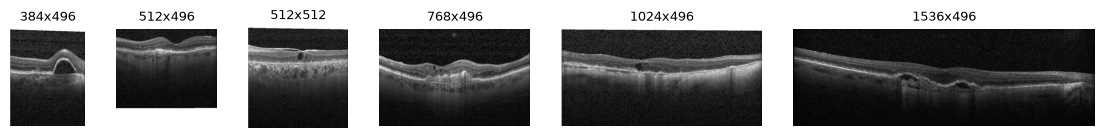

In [10]:
rows = []
example_per_size = {}
for cls in config.CLASSES:
    for img in (config.TRAINING_DIR / cls).glob('*.jpeg'):
        w, h = Image.open(img).size
        rows.append({'size': f'{w}x{h}', 'class': cls})
        if f'{w}x{h}' not in example_per_size:
            example_per_size[f'{w}x{h}'] = img

df = pd.DataFrame(rows)

ct = pd.crosstab(df['size'], df['class'])
ct.insert(4, 'TOTAL IMAGES', ct.sum(axis=1))
ct.insert(5, 'RATIO', [round(int(s.split('x')[0]) / int(s.split('x')[1]), 2)
                       for s in ct.index])
print(ct)

# one example image per size, drawn at its true aspect ratio and ordered by width
sizes = sorted(example_per_size, key=lambda s: int(s.split("x")[0]))
widths = [int(s.split("x")[0]) for s in sizes]

fig, axes = plt.subplots(1, len(sizes), figsize=(14, 3),
                         gridspec_kw={"width_ratios": widths})
for ax, size in zip(axes, sizes):
    ax.imshow(Image.open(example_per_size[size]), cmap="gray")
    ax.set_title(size, fontsize=9)
    ax.axis("off")
plt.show()

**Finding.** The scans do not all share the same size. The table above reports how many images of each size belong to each class, and the figure shows one representative image per size drawn at its true aspect ratio. The scanner produces a fixed height with a variable width, so five of the six sizes share the height of 496. The exception is the 512 by 512 size, which is the only size that never contains CNV or DRUSEN and holds only DME and NORMAL images. Size alone therefore carries information about the class, and the preprocessing must remove this cue.

## Image dimensions across the three devices

The previous table considered Kermany alone, where size is predictive of class. This section compares the native sizes of all three sets, namely the training set and the two evaluation sets. The differences in size and aspect ratio between devices are the reason that the preprocessing developed in the next notebook is necessary.

            set     n    width   height     ratio  distinct sizes
Kermany (train) 83484 384-1536  496-512 0.77-3.10               6
 OCTDL (unseen)  1137 444-1270  127-710 1.44-4.28             394
Clinic (target)    37 682-1475 236-1056 1.40-2.89               6


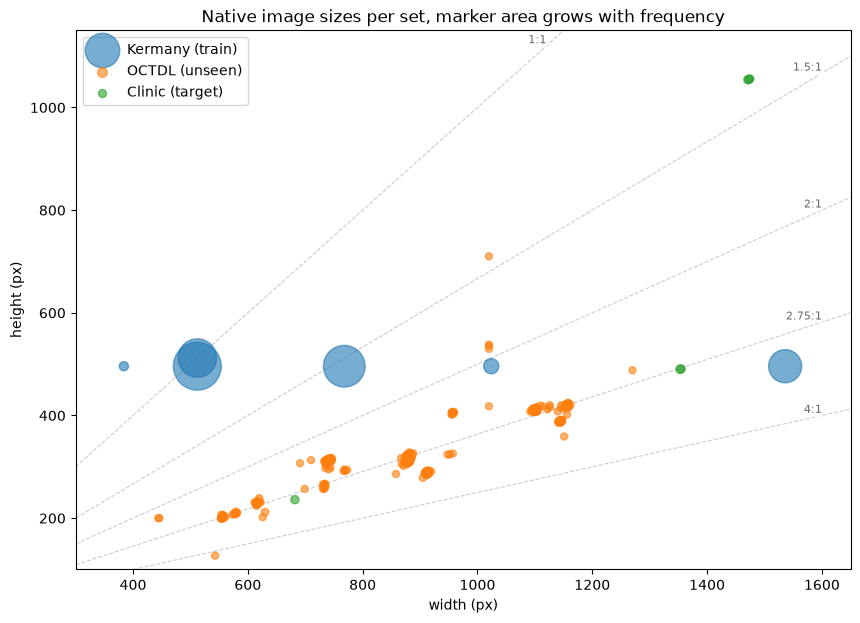

In [11]:
sets = {
    "Kermany (train)": [p for cls in config.CLASSES
                        for p in (config.TRAINING_DIR / cls).glob("*.jpeg")],
    "OCTDL (unseen)":  [p for p in (config.DATA_DIR / "raw" / "octdl_dl" / "OCTDL").glob("*/*")
                        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}],
    "Clinic (target)": list((config.DATA_DIR / "raw" / "bscans").glob("*.png")),
}

# native width and height for every image in every set
dims = {name: [Image.open(f).size for f in files] for name, files in sets.items()}

# summary of count, width and height and ratio ranges, and number of distinct sizes
rows = []
for name, ds in dims.items():
    ws, hs = zip(*ds)
    ratios = [w / h for w, h in ds]
    rows.append({"set": name, "n": len(ds),
                 "width":  f"{min(ws)}-{max(ws)}",
                 "height": f"{min(hs)}-{max(hs)}",
                 "ratio":  f"{min(ratios):.2f}-{max(ratios):.2f}",
                 "distinct sizes": len(set(ds))})
print(pd.DataFrame(rows).to_string(index=False))

# scatter of native sizes per set, marker area grows with frequency
fig, ax = plt.subplots(figsize=(10, 7))

# faint guide lines for constant width to height ratios, each labelled with its ratio
for ratio in (1, 1.5, 2, 2.75, 4):
    x = np.array([300, 1650])
    ax.plot(x, x / ratio, ls="--", lw=0.8, color="0.8", zorder=0)
    x_lab = min(1600, ratio * 1120)
    ax.text(x_lab, x_lab / ratio, f"{ratio:g}:1", fontsize=8, color="0.4",
            ha="right", va="bottom", zorder=1,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

for name, ds in dims.items():
    counts = Counter(ds)
    ws   = [w for (w, h) in counts]
    hs   = [h for (w, h) in counts]
    area = [20 + 6 * np.sqrt(counts[(w, h)]) for (w, h) in counts]
    ax.scatter(ws, hs, s=area, alpha=0.6, label=name)

ax.set_xlim(300, 1650)
ax.set_ylim(100, 1150)
ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Native image sizes per set, marker area grows with frequency")
ax.legend()
plt.show()

**Interpretation.** Each device occupies a different region of the size and ratio space, so a network trained on one device cannot assume the frame shape of another. Two observations follow from the ratio ranges. First, the clinic ratios of 1.40 to 2.89 fall inside the Kermany range of 0.77 to 3.10, so the target is an interpolation of shapes already present in training, which is what later makes a plain resize defensible. Second, OCTDL reaches 4.28, beyond the widest Kermany ratio of 3.10, so some evaluation images are more elongated than anything seen in training. This is a genuine extrapolation at the wide end, and a region in which the model may struggle unless the preprocessing normalises it.

## The three devices side by side

The following cell displays one healthy retina from each device, so that the only difference between the panels is the scanner that produced the image.

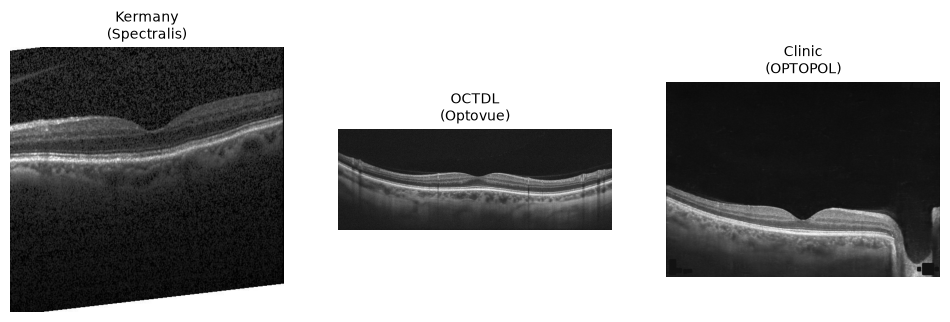

In [12]:
machines = {
    "Kermany\n(Spectralis)": sorted((config.TRAINING_DIR / "NORMAL").glob("*.jpeg"))[0],
    "OCTDL\n(Optovue)": sorted((config.DATA_DIR / "raw" / "octdl_dl" / "OCTDL" / "NO").glob("*"))[0],
    "Clinic\n(OPTOPOL)": sorted((config.DATA_DIR / "raw" / "bscans").glob("NORMAL*.png"))[0],
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, path) in zip(axes, machines.items()):
    ax.imshow(Image.open(path), cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.show()

**Observation.** All three panels show a healthy retina, yet they differ markedly. The Kermany scan is grainy and tall. The OCTDL scan has a different width and framing. The clinic scan consists largely of dark background with a tilted retina. A network trained on one of these images cannot read the others without adjustment, which is the motivation for the preprocessing pipeline developed in the next notebook.

## Summary

Three properties of the data were established before modelling.

1. The provided split leaks. 89 percent of the test patients also appear in training, so a patient level split was constructed with zero leakage.
2. The images vary in size and aspect ratio, and one size is specific to a subset of classes, so the preprocessing must normalise size.
3. The classes are imbalanced and the three devices differ substantially in appearance.

The notebook produced split.csv, a clean patient level split of all 83,484 images, which the preprocessing notebook consumes.